In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better-looking plots
plt.style.use("ggplot")

# Display all columns
pd.set_option("display.max_columns", None)

In [6]:
#Cell 2 – Load Clean Dataset
df = pd.read_csv("../data/processed/telco_churn_clean.csv")

In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  \
0              No  No phone service             DSL      

In [10]:
#Load Clean Dataset
df = pd.read_csv("../data/processed/telco_churn_clean.csv")

In [11]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

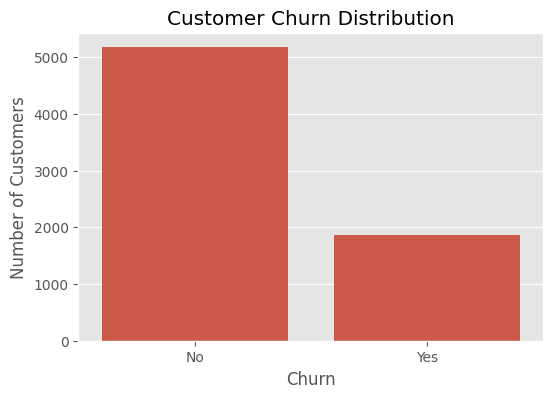

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

**Numerical Feature Analysis**

Do customers who stay longer churn less?

1.Tenure


In [14]:
df["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

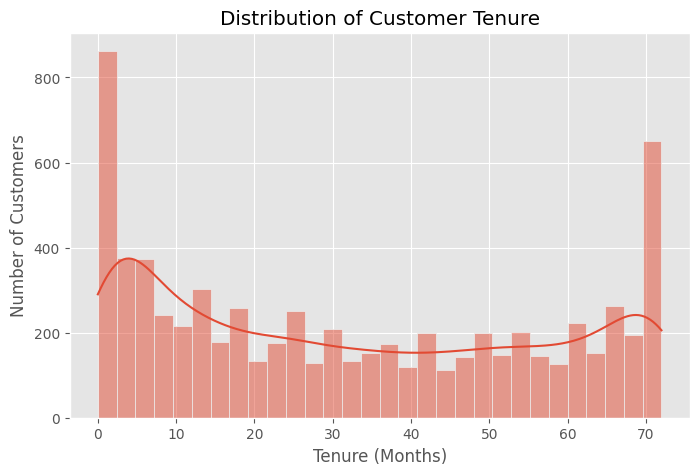

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["tenure"], bins=30, kde=True)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

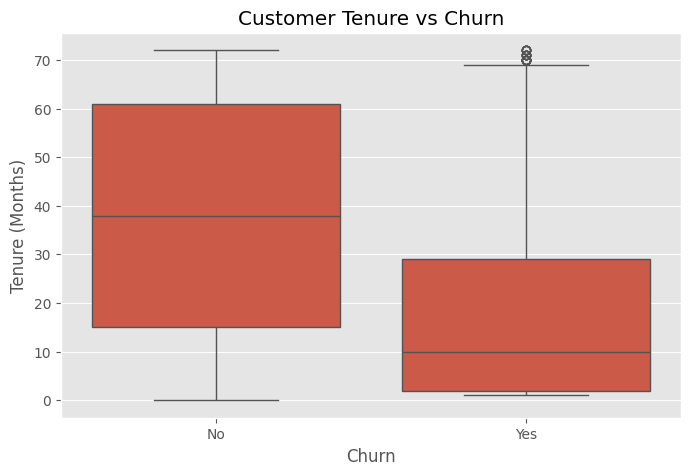

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

2.MonthlyhCharges

Do customers who pay higher monthly charges churn more?

In [17]:
df["MonthlyCharges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

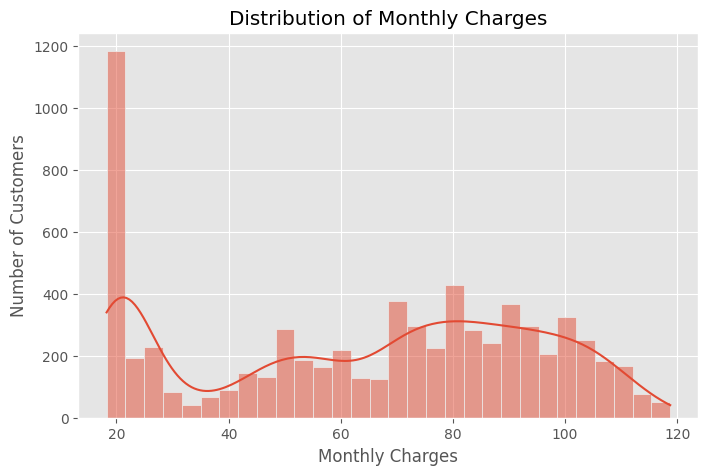

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyCharges"], bins=30, kde=True)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

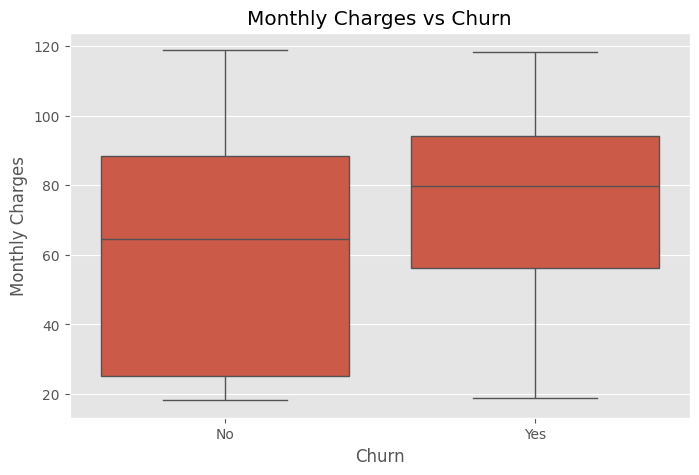

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

3.Contract

Which customers can leave the company most easily?

In [20]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [21]:
df["Contract"].value_counts(normalize=True) * 100

Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64

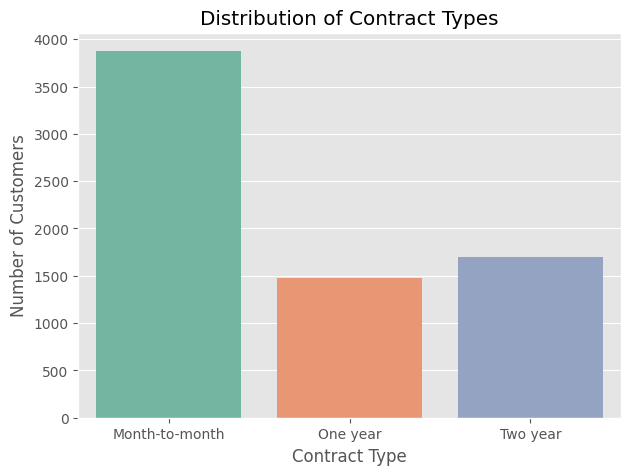

In [22]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Contract",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Contract Types")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

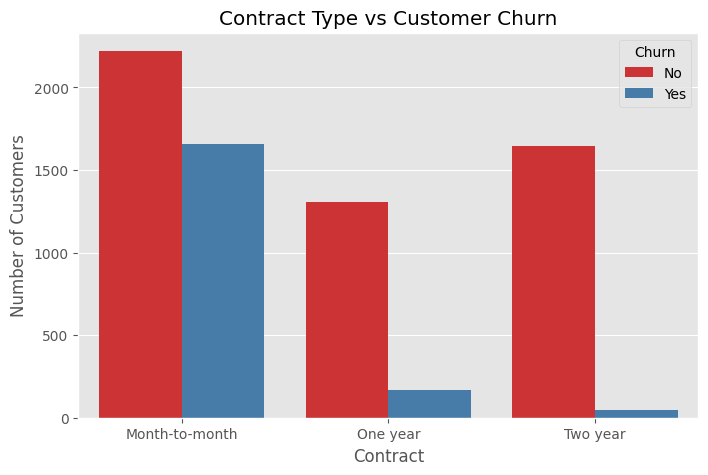

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn",
    palette="Set1"
)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")

plt.show()

In [24]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


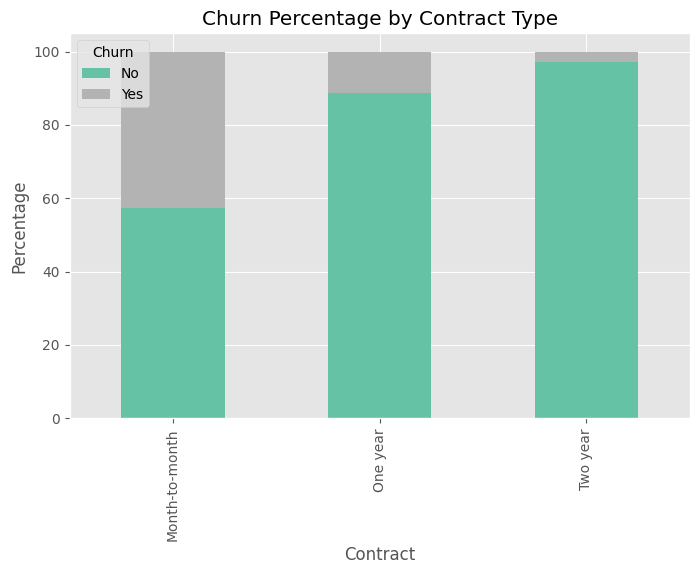

In [25]:
contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    colormap="Set2"
)

plt.title("Churn Percentage by Contract Type")
plt.ylabel("Percentage")

plt.show()

4.InternetService

Customers with No Internet should churn the most because they're using fewer services

In [26]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [27]:
df["InternetService"].value_counts(normalize=True) * 100

InternetService
Fiber optic    43.958540
DSL            34.374556
No             21.666903
Name: proportion, dtype: float64

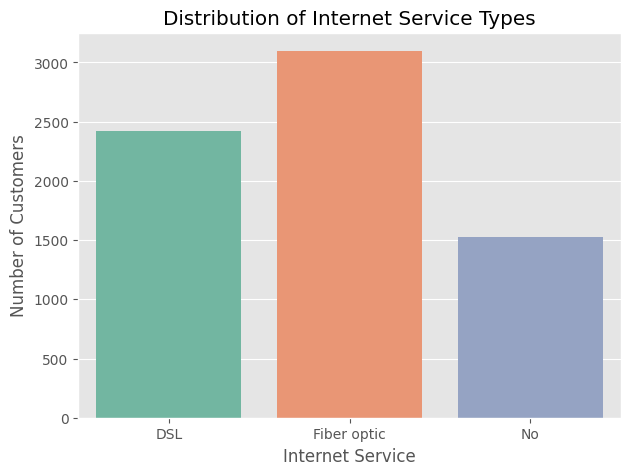

In [28]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="InternetService",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Internet Service Types")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

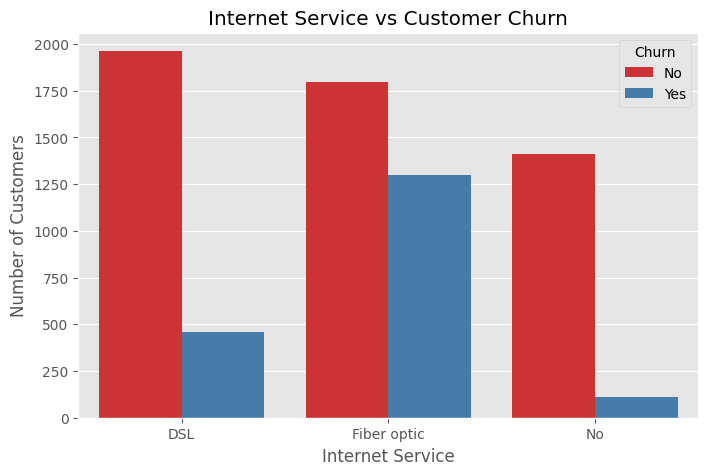

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn",
    palette="Set1"
)

plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

In [30]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


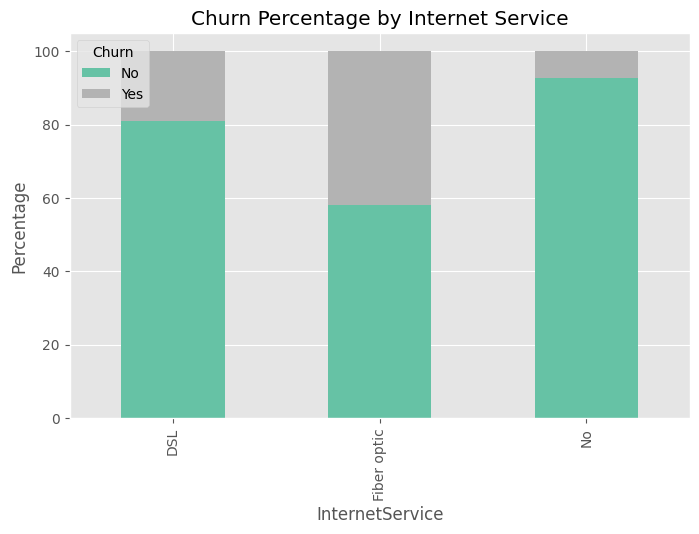

In [31]:
internet_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    colormap="Set2"
)

plt.title("Churn Percentage by Internet Service")
plt.ylabel("Percentage")

plt.show()

5.PaymentMethod

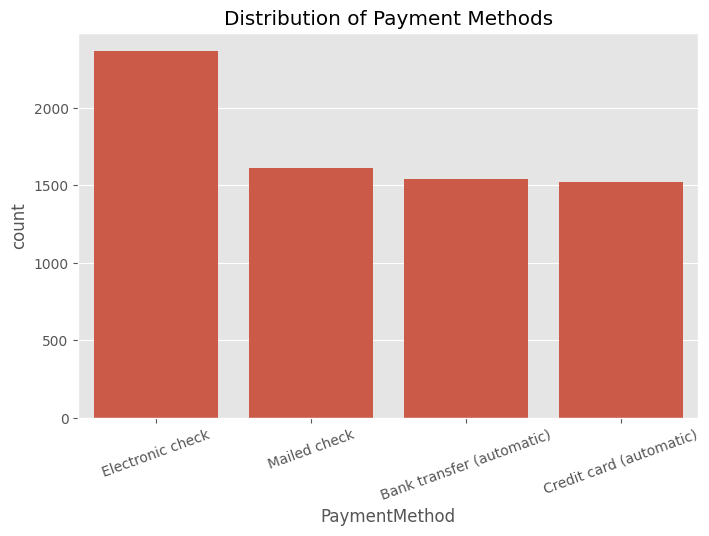

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    order=df["PaymentMethod"].value_counts().index
)

plt.xticks(rotation=20)
plt.title("Distribution of Payment Methods")
plt.show()

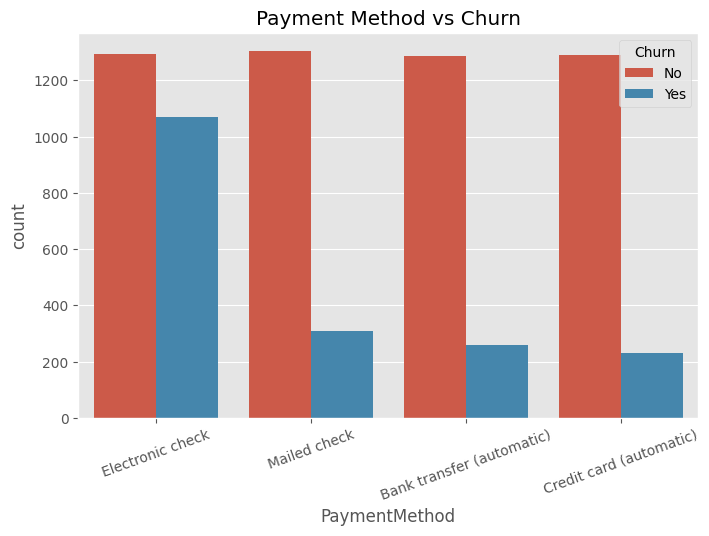

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn",
    order=df["PaymentMethod"].value_counts().index
)

plt.xticks(rotation=20)
plt.title("Payment Method vs Churn")
plt.show()

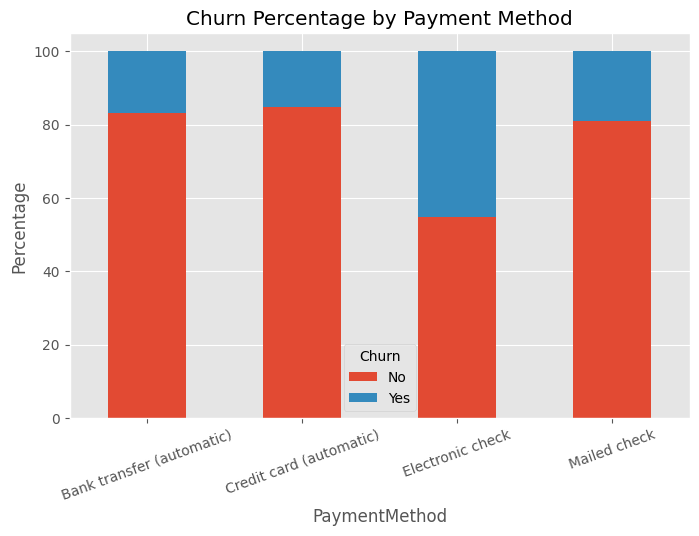

In [34]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.ylabel("Percentage")
plt.title("Churn Percentage by Payment Method")
plt.xticks(rotation=20)
plt.show()

In [35]:
payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


6.OnlineSecurity

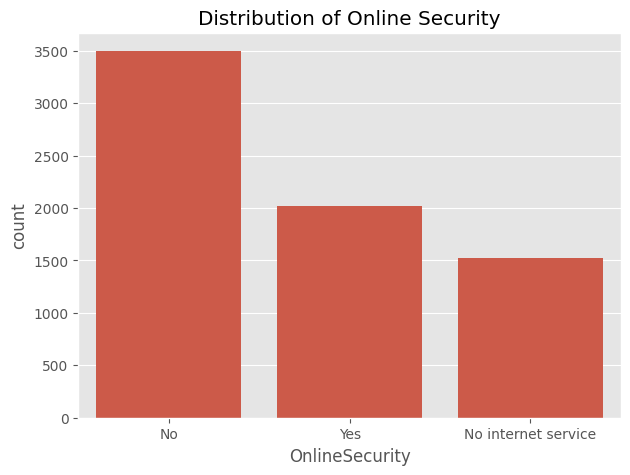

In [36]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="OnlineSecurity",
    order=df["OnlineSecurity"].value_counts().index
)

plt.title("Distribution of Online Security")
plt.show()

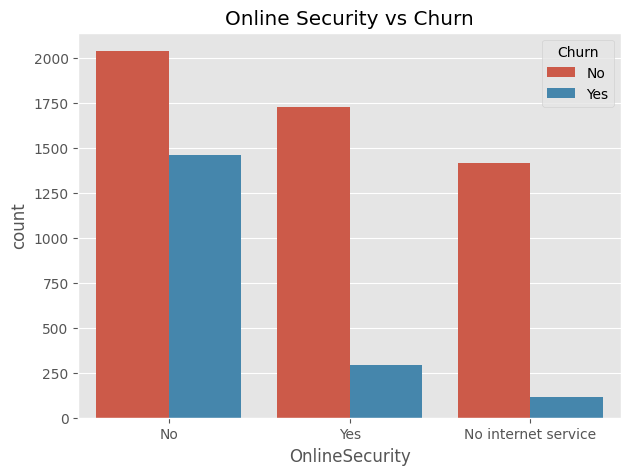

In [37]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="OnlineSecurity",
    hue="Churn",
    order=df["OnlineSecurity"].value_counts().index
)

plt.title("Online Security vs Churn")
plt.show()

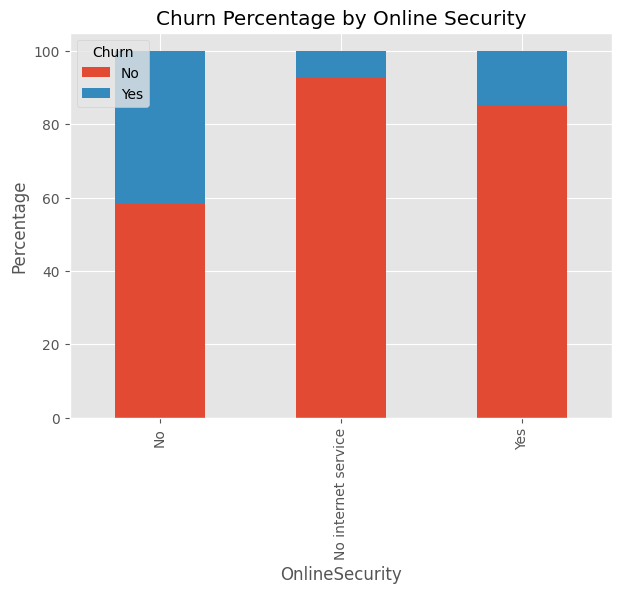

In [38]:
security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

security_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5)
)

plt.ylabel("Percentage")
plt.title("Churn Percentage by Online Security")
plt.show()

In [39]:
security_churn

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def analyze_categorical(feature):

    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(18,5))

    # -----------------------------
    # Distribution Plot
    # -----------------------------
    sns.countplot(
        data=df,
        x=feature,
        order=df[feature].value_counts().index,
        ax=axes[0]
    )
    axes[0].set_title(f"Distribution of {feature}")
    axes[0].tick_params(axis='x', rotation=20)

    # -----------------------------
    # Count Plot vs Churn
    # -----------------------------
    sns.countplot(
        data=df,
        x=feature,
        hue="Churn",
        order=df[feature].value_counts().index,
        ax=axes[1]
    )
    axes[1].set_title(f"{feature} vs Churn")
    axes[1].tick_params(axis='x', rotation=20)

    # -----------------------------
    # Percentage Plot
    # -----------------------------
    temp = pd.crosstab(
        df[feature],
        df["Churn"],
        normalize="index"
    ) * 100

    temp.plot(
        kind="bar",
        stacked=True,
        ax=axes[2]
    )

    axes[2].set_title(f"Churn % by {feature}")
    axes[2].set_ylabel("Percentage")
    axes[2].tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.show()

    # Display percentage table
    print("\nChurn Percentage Table:\n")
    display(temp.round(2))

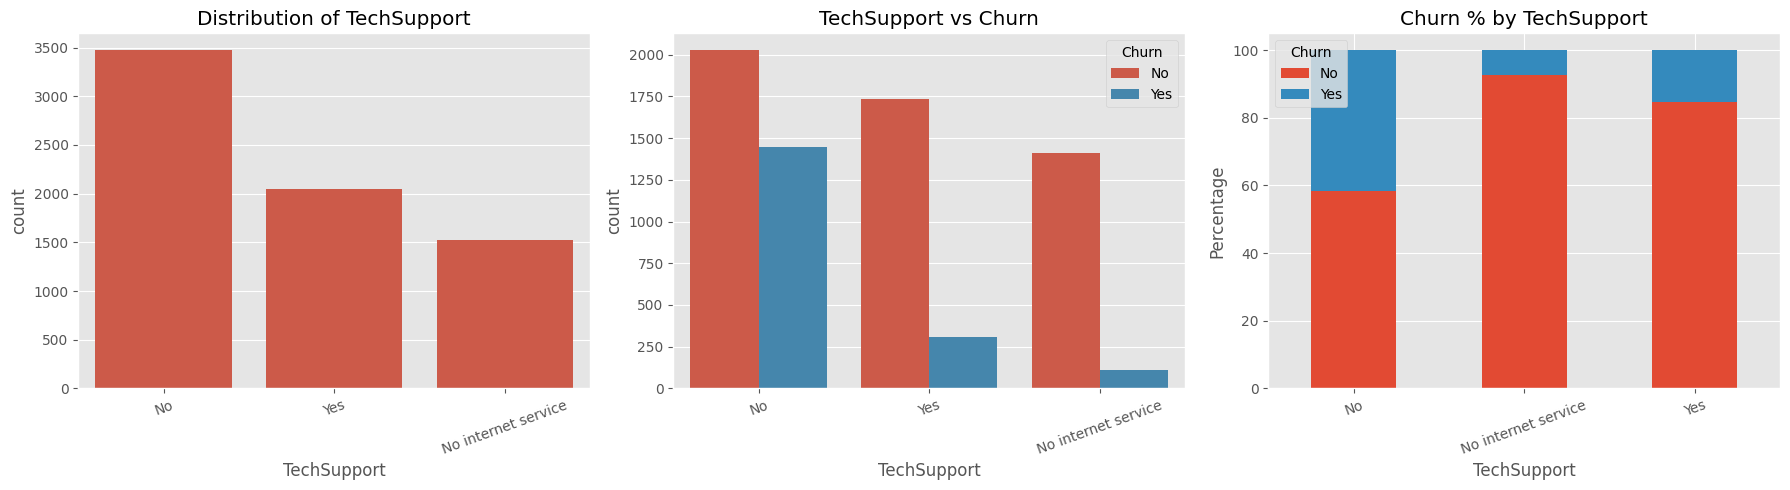


Churn Percentage Table:



Churn,No,Yes
TechSupport,,
No,58.36,41.64
No internet service,92.60,7.40
Yes,84.83,15.17


In [42]:
analyze_categorical("TechSupport")


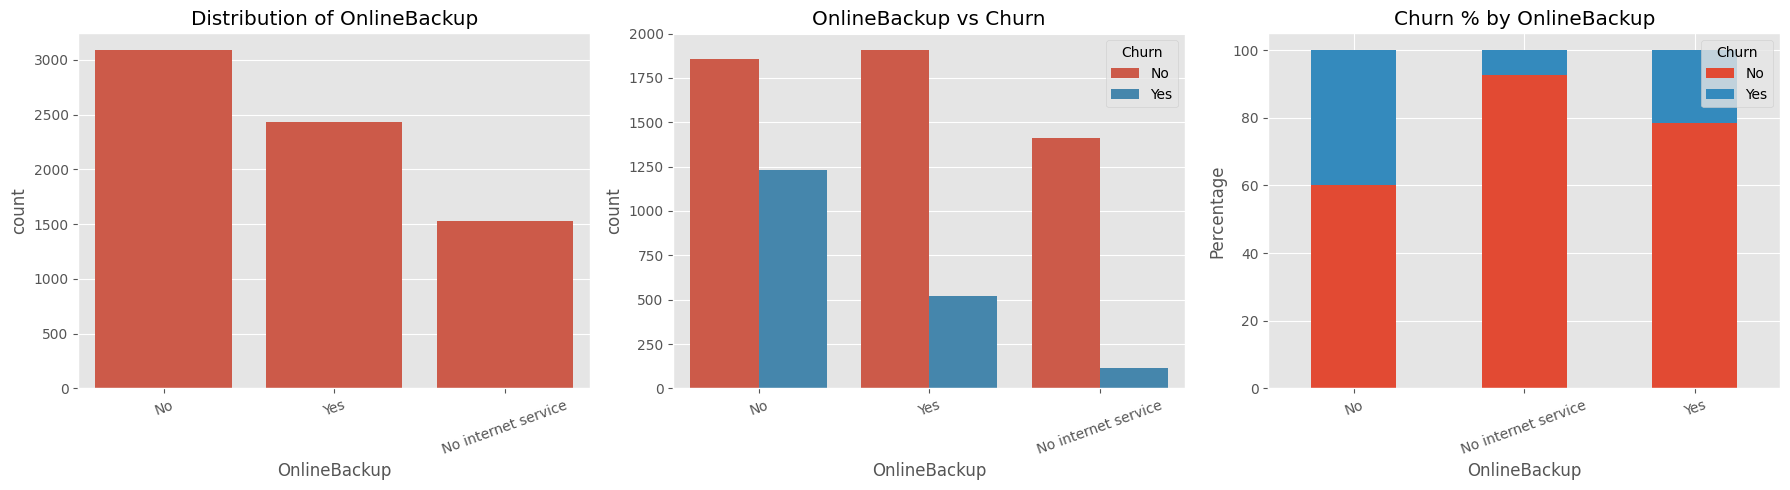


Churn Percentage Table:



Churn,No,Yes
OnlineBackup,,
No,60.07,39.93
No internet service,92.60,7.40
Yes,78.47,21.53


In [43]:
analyze_categorical("OnlineBackup")


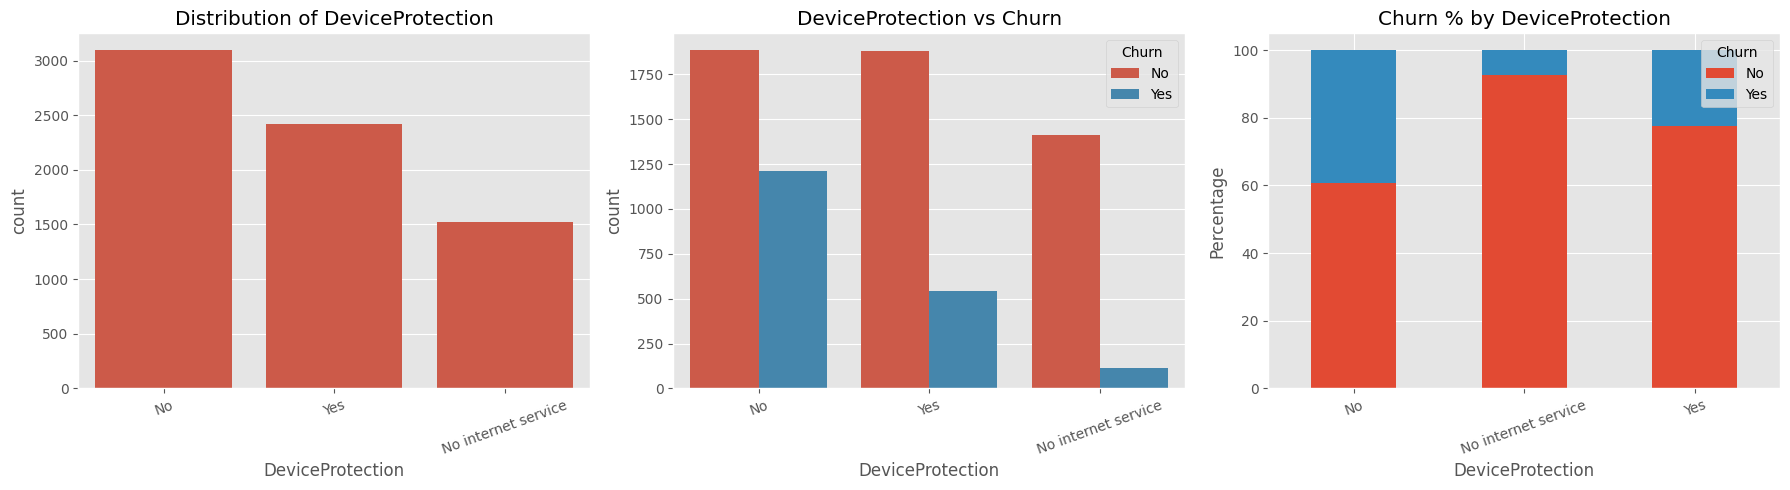


Churn Percentage Table:



Churn,No,Yes
DeviceProtection,,
No,60.87,39.13
No internet service,92.60,7.40
Yes,77.50,22.50


In [44]:
analyze_categorical("DeviceProtection")


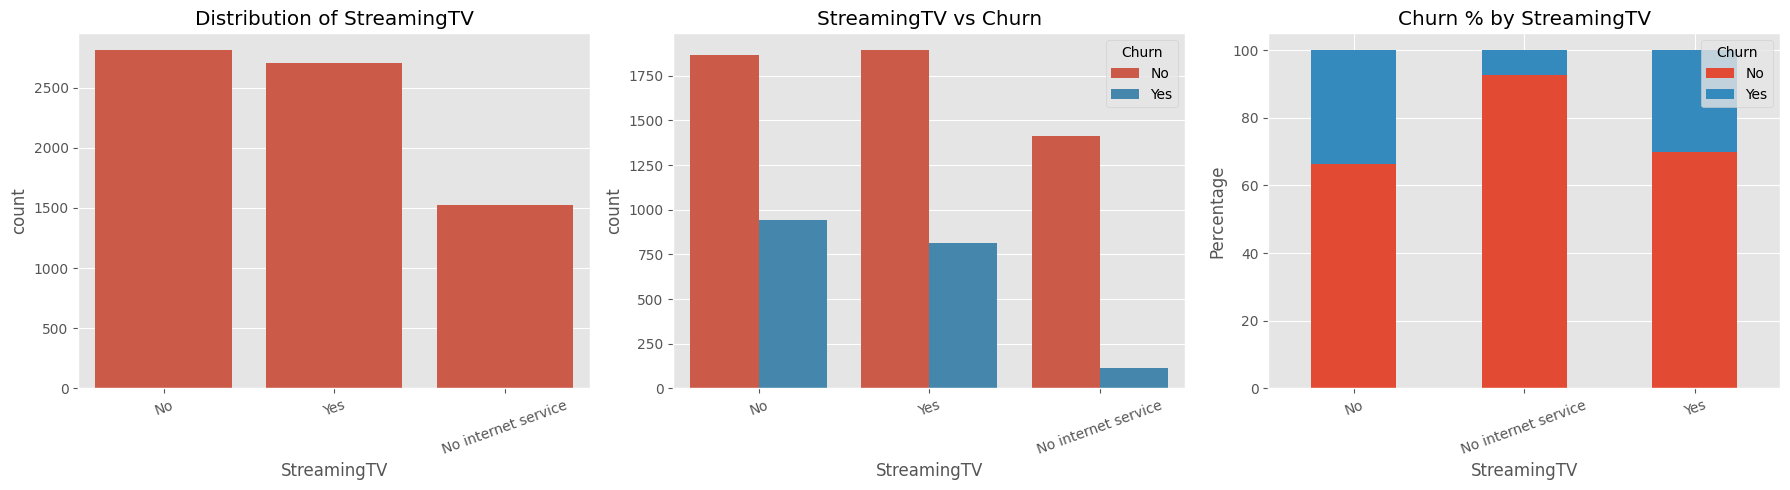


Churn Percentage Table:



Churn,No,Yes
StreamingTV,,
No,66.48,33.52
No internet service,92.60,7.40
Yes,69.93,30.07


In [45]:
analyze_categorical("StreamingTV")


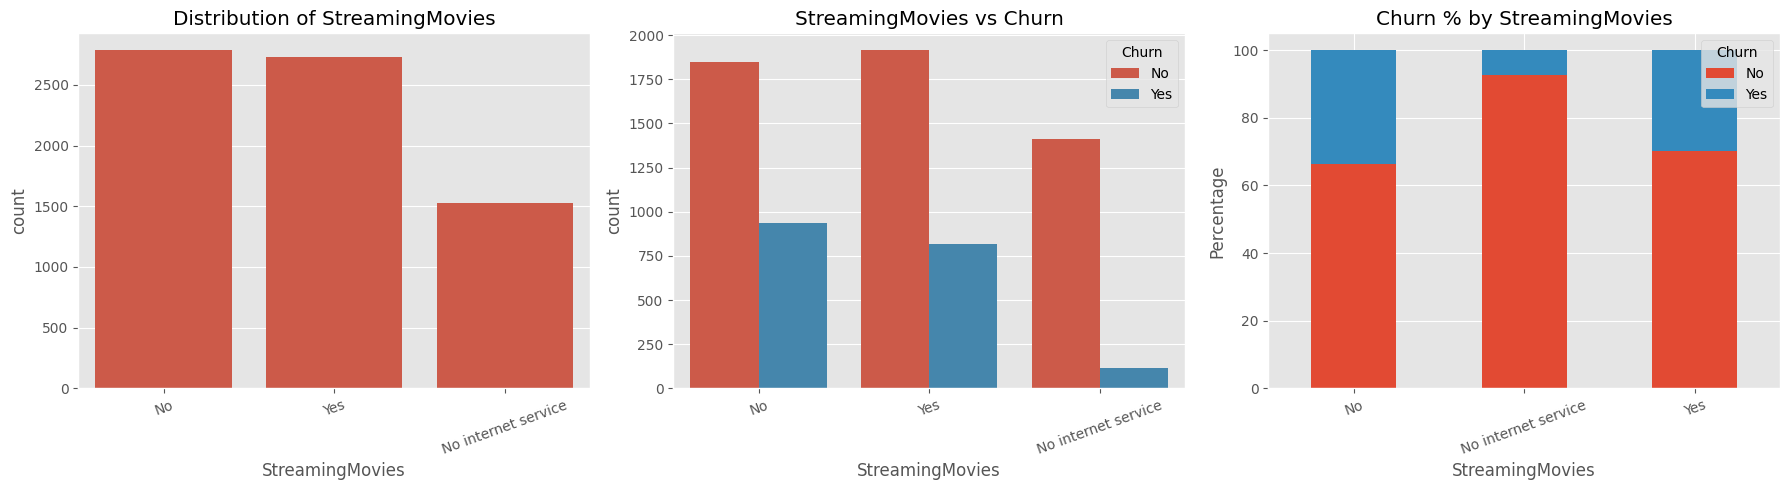


Churn Percentage Table:



Churn,No,Yes
StreamingMovies,,
No,66.32,33.68
No internet service,92.60,7.40
Yes,70.06,29.94


In [46]:
analyze_categorical("StreamingMovies")

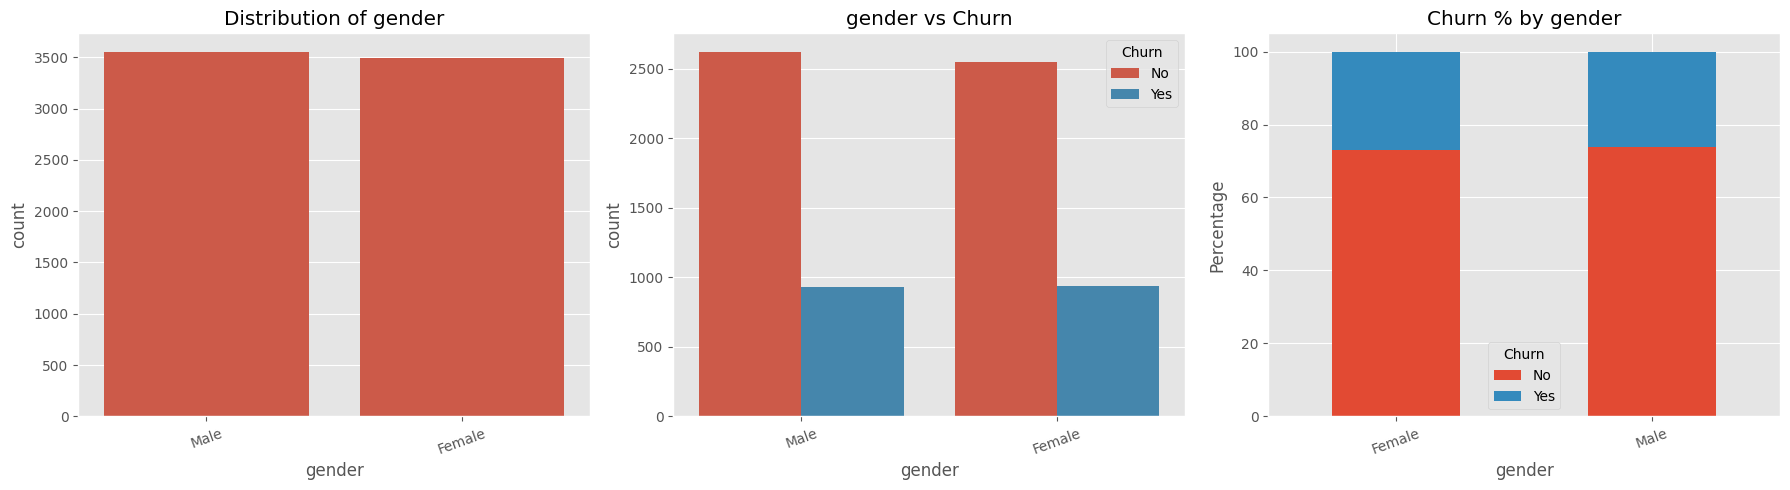


Churn Percentage Table:



Churn,No,Yes
gender,,
Female,73.08,26.92
Male,73.84,26.16


In [47]:
analyze_categorical("gender")

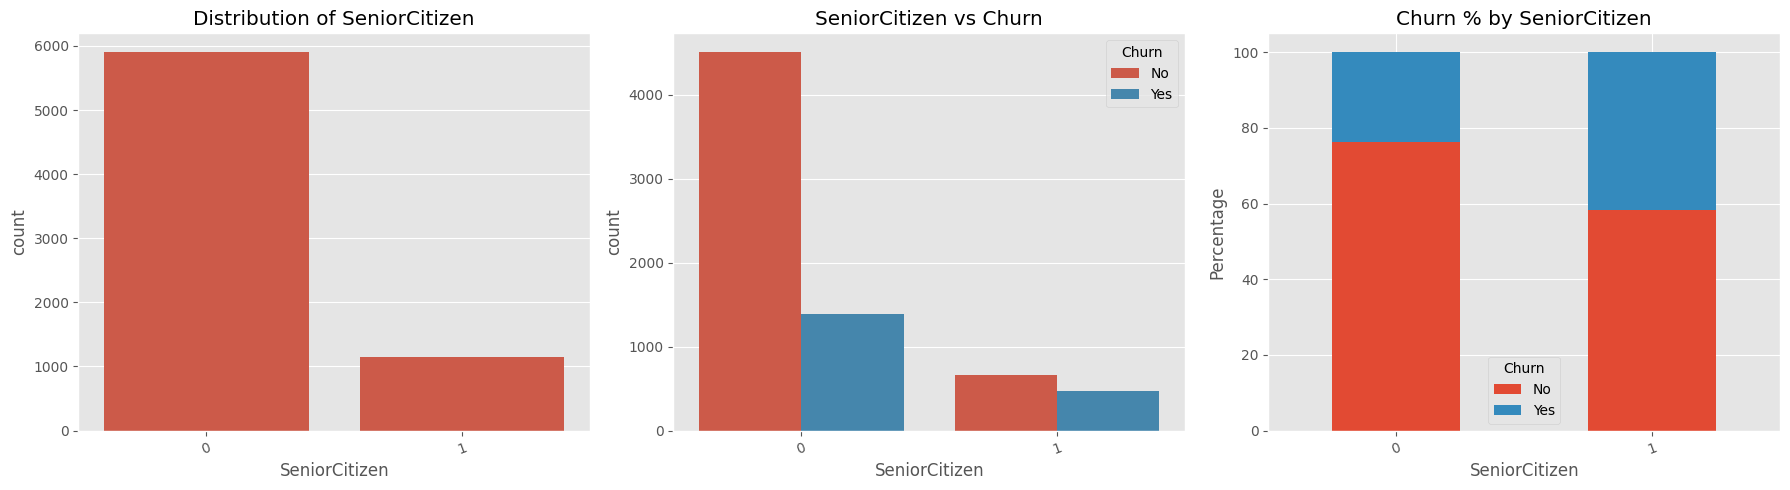


Churn Percentage Table:



Churn,No,Yes
SeniorCitizen,,
0,76.39,23.61
1,58.32,41.68


In [ ]:
analyze_categorical("SeniorCitizen")

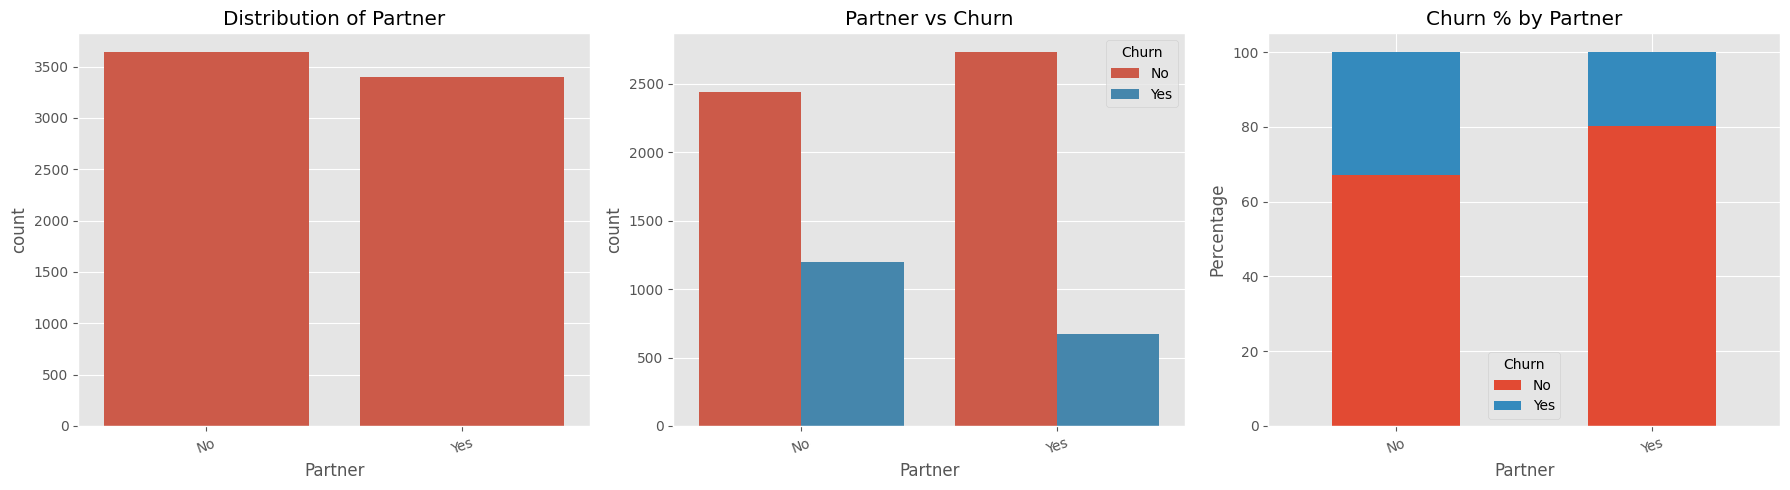


Churn Percentage Table:



Churn,No,Yes
Partner,,
No,67.04,32.96
Yes,80.34,19.66


In [49]:
analyze_categorical("Partner")

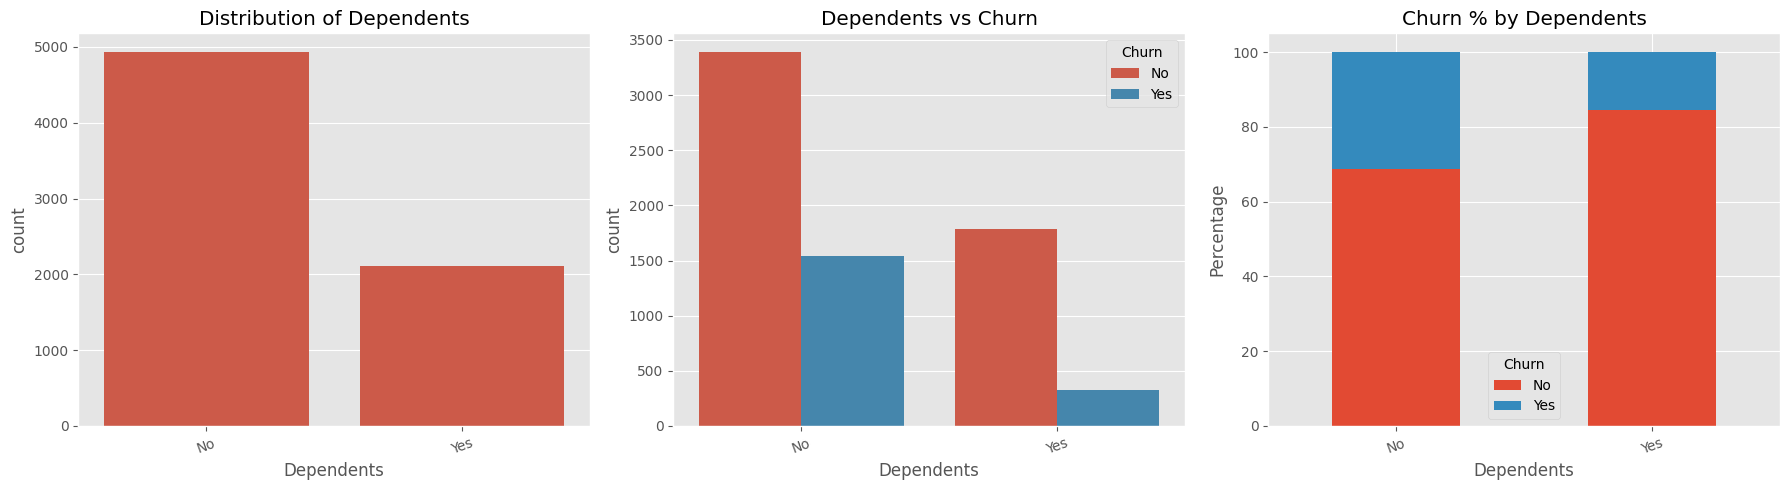


Churn Percentage Table:



Churn,No,Yes
Dependents,,
No,68.72,31.28
Yes,84.55,15.45


In [50]:
analyze_categorical("Dependents")

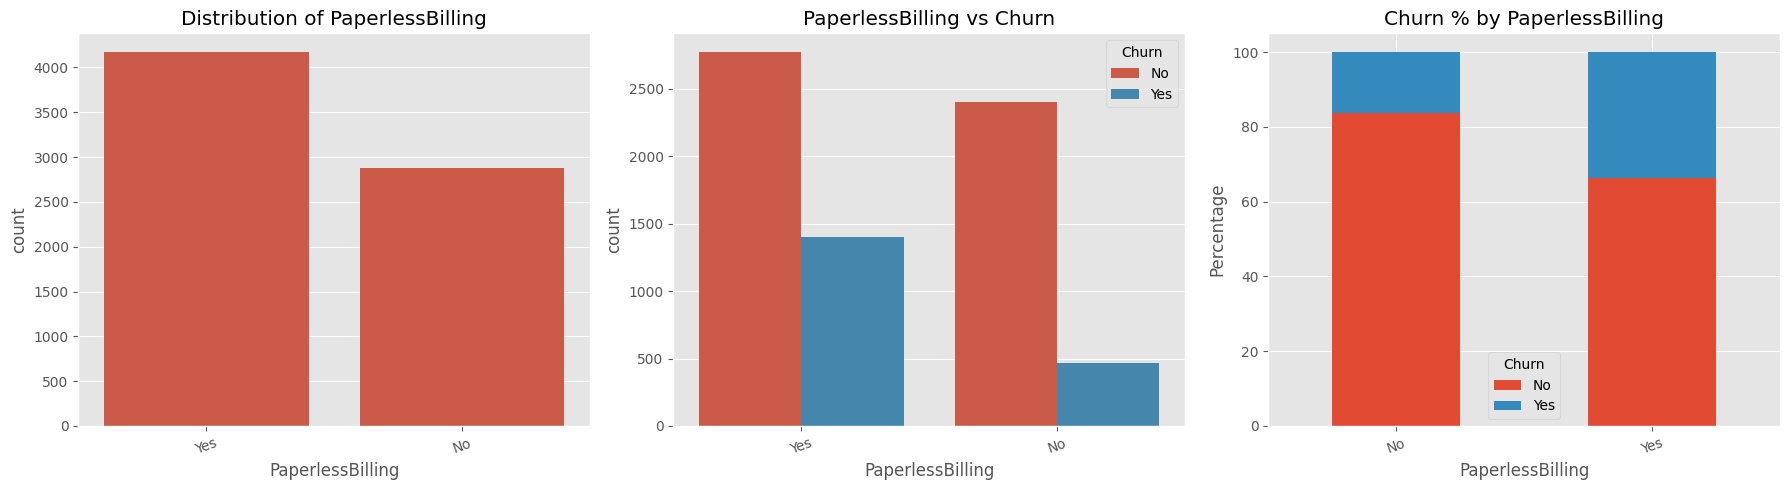


Churn Percentage Table:



Churn,No,Yes
PaperlessBilling,,
No,83.67,16.33
Yes,66.43,33.57


In [51]:
analyze_categorical("PaperlessBilling")